In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input, Dense, Flatten, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

In [2]:
# Tải MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize: pixel về [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Thêm channel dimension: (N, 28, 28) → (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test,  axis=-1)

print(f"Train: {x_train.shape}")  # (60000, 28, 28, 1)
print(f"Test:  {x_test.shape}")   # (10000, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)
Test:  (10000, 28, 28, 1)


In [3]:
# ── Hyperparameter ──────────────────────────────────────
latent_dim = 32  # Kích thước không gian ẩn (bottleneck)

# ── ENCODER ─────────────────────────────────────────────
inputs = Input(shape=(28, 28, 1), name='encoder_input')
x = Flatten()(inputs)                    # 28×28×1 → 784
encoded = Dense(latent_dim, activation='relu')(x)  # 784 → 32

encoder = Model(inputs, encoded, name='encoder')

# ── DECODER ─────────────────────────────────────────────
latent_inputs = Input(shape=(latent_dim,), name='decoder_input')
x = Dense(784, activation='sigmoid')(latent_inputs)  # 32 → 784
decoded = Reshape((28, 28, 1))(x)               # 784 → 28×28×1

decoder = Model(latent_inputs, decoded, name='decoder')

# ── AUTO ENCODER = Encoder + Decoder ────────────────────
ae_input  = Input(shape=(28, 28, 1))
ae_latent = encoder(ae_input)
ae_output = decoder(ae_latent)

autoencoder = Model(ae_input, ae_output, name='autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0702 - val_loss: 0.0415
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0352 - val_loss: 0.0294
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0264 - val_loss: 0.0231
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0214 - val_loss: 0.0193
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0183 - val_loss: 0.0166
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0161 - val_loss: 0.0149
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0146 - val_loss: 0.0136
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134 - val_loss: 0.0125
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0125 - val_loss: 0.0118
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0118 - val_loss: 0.0112
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0114 - val_loss: 0.0108
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

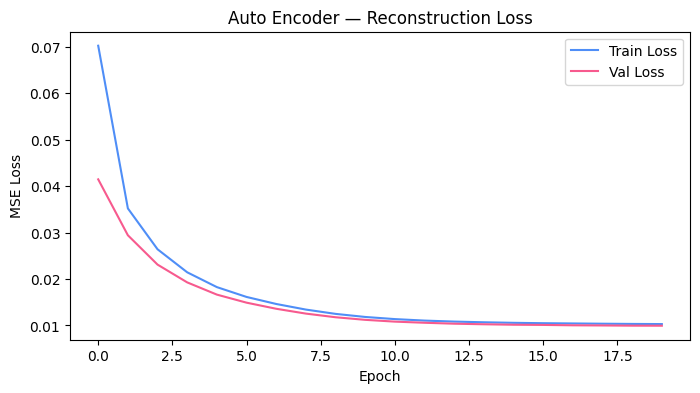

In [4]:
# Compile với MSE loss (so sánh pixel)
autoencoder.compile(
    optimizer='adam',
    loss='mse'          # hoặc 'binary_crossentropy'
)

# Huấn luyện: input = output = x_train (self-supervised)
history = autoencoder.fit(
    x_train, x_train,         # input và target giống nhau!
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss', color='#4f8ef7')
plt.plot(history.history['val_loss'], label='Val Loss', color='#f75a8e')
plt.title('Auto Encoder — Reconstruction Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


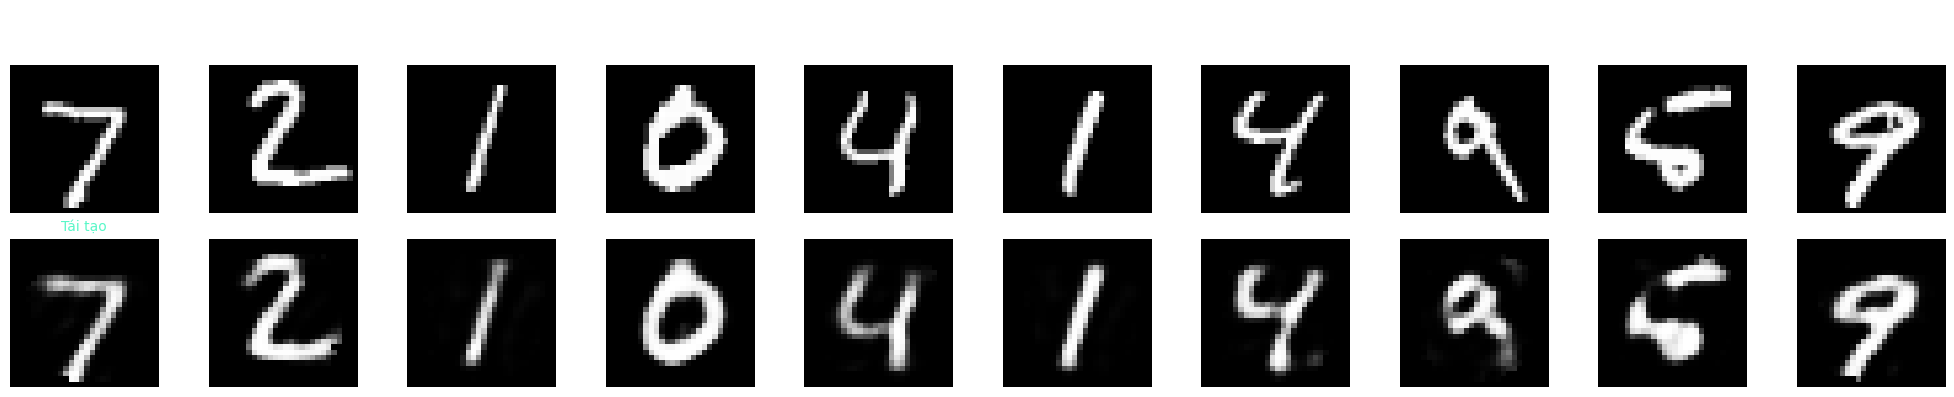

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Latent space shape: (1000, 32)


In [6]:
n = 10  # số ảnh muốn hiển thị
# Tái tạo ảnh từ tập test
x_reconstructed = autoencoder.predict(x_test[:n])

fig, axes = plt.subplots(2, n, figsize=(20, 4))

for i in range(n):
    # Hàng 1: ảnh gốc
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Gốc', fontsize=10, color='white')

    # Hàng 2: ảnh tái tạo
    axes[1, i].imshow(x_reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Tái tạo', fontsize=10, color='#5af7c8')

plt.suptitle('Auto Encoder — MNIST Reconstruction', color='white', fontsize=13)
plt.tight_layout(); plt.show()

# Tách riêng Encoder để xem latent space
z = encoder.predict(x_test[::10])  # lấy mỗi 10 ảnh 1 ảnh
print(f"Latent space shape: {z.shape}")  # (1000, 32)